In [0]:
from pyspark.sql import functions as F

# Lectura inicial
df = spark.read.csv(
    "/Workspace/Users/sol.serna@est.iudigital.edu.co/healthcare_dataset.csv",
    header=True,
    sep=";",
    inferSchema=True
)

print("✅ Dataset cargado correctamente.")
df.show(5)

✅ Dataset cargado correctamente.
+---+-------------+---+------+----------+-----------------+-----------------+----------------+--------------------+------------------+--------------------+-----------+--------------+--------------+-----------+------------+
| Id|         Name|Age|Gender|Blood Type|Medical Condition|Date of Admission|          Doctor|            Hospital|Insurance Provider|      Billing Amount|Room Number|Admission Type|Discharge Date| Medication|Test Results|
+---+-------------+---+------+----------+-----------------+-----------------+----------------+--------------------+------------------+--------------------+-----------+--------------+--------------+-----------+------------+
|  1|Bobby JacksOn| 30|  Male|        B-|           Cancer|       2024-01-31|   Matthew Smith|     Sons and Miller|        Blue Cross|18.856.281.305.97...|        328|        Urgent|    2024-02-02|Paracetamol|      Normal|
|  2| LesLie TErRy| 62|  Male|        A+|          Obesity|       2019-08-2

# Limpieza: evidencia antes/después


Se aplicó proceso de limpieza para estandarizar variables categóricas críticas como 
- Name 
- Gender
- Medical Condition

Adicionalmente, se eliminaron registros duplicados mediante dropDuplicates() para garantizar consistencia y evitar sesgos en los análisis descriptivos.
Esto mejora la calidad de los datos y permite realizar agrupaciones y visualizaciones más confiables.

In [0]:
from pyspark.sql import functions as F

# 1. EVIDENCIA ANTES (Seleccionamos las columnas con errores)
# Usamos limit(5) igual que tu compañera para ver solo los primeros
print("--- ANTES DE LIMPIEZA ---")
display(df.select("Name", "Gender", "Medical Condition").limit(5))


# 2. IMPLEMENTACIÓN DE LIMPIEZA
# En PySpark usamos 'initcap' para poner Mayúscula Inicial (Title Case)
# Y 'withColumn' para modificar la columna existente

df_limpio = df.withColumn(
    "Name", F.initcap(F.col("Name"))
).withColumn(
    "Gender", F.initcap(F.col("Gender"))
).withColumn(
    "Medical Condition", F.initcap(F.col("Medical Condition"))
)


# Eliminación de espacios
df_limpio = df_limpio.withColumn(
    "Name", F.trim(F.col("Name"))
).withColumn(
    "Gender", F.trim(F.col("Gender"))
).withColumn(
    "Medical Condition", F.trim(F.col("Medical Condition"))
)

# Limpieza de duplicados en PySpark
df_limpio = df_limpio.dropDuplicates()


# 3. EVIDENCIA DESPUÉS
print("--- DESPUÉS DE LIMPIEZA ---")
display(df_limpio.select("Name", "Gender", "Medical Condition").limit(5))

print("Registros antes:", df.count())
print("Registros después:", df_limpio.count())
print("Duplicados eliminados:", df.count() - df_limpio.count())




--- ANTES DE LIMPIEZA ---


Name,Gender,Medical Condition
Bobby JacksOn,Male,Cancer
LesLie TErRy,Male,Obesity
DaNnY sMitH,Female,Obesity
andrEw waTtS,Female,Diabetes
adrIENNE bEll,Female,Cancer


--- DESPUÉS DE LIMPIEZA ---


Name,Gender,Medical Condition
Sergio Sanchez,Male,Cancer
Christina Moore,Female,Arthritis
Melissa Hall,Female,Diabetes
Ashley Gray,Male,Asthma
Jennifer Cooper,Male,Obesity


Registros antes: 55500
Registros después: 55500
Duplicados eliminados: 0


- Se identificaron inconsistencias en valores categóricos, como diferencias en mayúsculas/minúsculas y espacios innecesarios, que afectan el análisis de datos.
- Se aplicaron transformaciones para normalizar el texto y eliminar espacios.
- se eliminaron registros duplicados para evitar sesgos en los conteos y agregaciones.
Después de la limpieza, se obtuvo un dataset más consistente y confiable para análisis estadístico.

# Transformaciones: columnas de fecha


Las transformaciones de fecha permiten extraer componentes temporales relevantes para el análisis.
anio y mes permiten estudiar estacionalidad e identificar cambios a lo largo del tiempo.
dia_semana y nombre_dia ayudan a detectar patrones por día, como comportamientos distintos entre días laborales y fines de semana.
Estas variables facilitarán el análisis descriptivo y permitirán generar agregaciones más útiles para visualizar tendencias.

In [0]:
from pyspark.sql import functions as F

# 1. Normalizar columnas
df_limpio = df_limpio.toDF(*[col.strip() for col in df_limpio.columns])

# 2. Crear fecha y derivadas
df_final = (
    df_limpio
    .withColumn("fecha", F.to_date(F.col("Discharge Date"), "d/M/yyyy"))
    .withColumn("anio", F.year("fecha"))
    .withColumn("mes", F.month("fecha"))
    .withColumn("dia", F.dayofmonth("fecha"))
    .withColumn("dia_semana", F.dayofweek("fecha"))
    .withColumn("nombre_dia", F.date_format("fecha", "EEEE"))
)

# 3. Evidencia antes y después
print("ANTES:")
display(df_limpio.select("Discharge Date").limit(5))

print("DESPUÉS:")
display(df_final.select("fecha").limit(5))

# 4. Validar valores nulos
print("Registros con fecha nula:", df_final.filter(df_final.fecha.isNull()).count())

# 5. Mostrar columnas nuevas
display(
    df_final.select("fecha", "anio", "mes", "dia", "dia_semana", "nombre_dia").limit(10)
)


ANTES:


Discharge Date
2020-05-20
2019-08-21
2022-08-14
2020-10-20
2020-05-02


DESPUÉS:


fecha
2020-05-20
2019-08-21
2022-08-14
2020-10-20
2020-05-02


Registros con fecha nula: 0


fecha,anio,mes,dia,dia_semana,nombre_dia
2020-05-20,2020,5,20,4,Wednesday
2019-08-21,2019,8,21,4,Wednesday
2022-08-14,2022,8,14,1,Sunday
2019-09-29,2019,9,29,1,Sunday
2020-03-20,2020,3,20,6,Friday
2021-06-16,2021,6,16,4,Wednesday
2020-10-20,2020,10,20,3,Tuesday
2020-05-02,2020,5,2,7,Saturday
2021-01-26,2021,1,26,3,Tuesday
2021-12-17,2021,12,17,6,Friday


# Nueva tabla: resumen por mes


In [0]:
from pyspark.sql import functions as F

# ============================================================
# 1. Generar resumen mensual descriptivo
# ============================================================

resumen_mensual = (
    df_final.groupBy("anio", "mes")
    .agg(
        F.count("*").alias("n_registros"),
        F.countDistinct("Hospital").alias("n_hospitales"),
        F.countDistinct("Doctor").alias("n_doctores"),
        F.countDistinct("Medical Condition").alias("n_condiciones"),
        F.countDistinct("Gender").alias("n_generos"),
        F.countDistinct("Medication").alias("n_medicamentos")
    )
    .orderBy("anio", "mes")
)
# ============================================================
# 2. Mostrar la tabla resumen


print("📊 RESUMEN MENSUAL")
display(resumen_mensual)

# =========================
# 3. Guardar como tabla 

resumen_mensual.write.mode("overwrite").saveAsTable("resumen_mensual")
print("💾 Tabla 'resumen_mensual' guardada correctamente.")


📊 RESUMEN MENSUAL


anio,mes,n_registros,n_hospitales,n_doctores,n_condiciones,n_generos,n_medicamentos
2019,5,278,248,250,6,2,5
2019,6,852,756,764,6,2,5
2019,7,915,821,825,6,2,5
2019,8,963,844,853,6,2,5
2019,9,1007,889,900,6,2,5
2019,10,928,835,827,6,2,5
2019,11,1044,920,932,6,2,5
2019,12,934,829,834,6,2,5
2020,1,946,835,841,6,2,5
2020,2,882,787,794,6,2,5


💾 Tabla 'resumen_mensual' guardada correctamente.


- El año 2019 muestra un aumento progresivo hasta llegar a máximos cercanos a 1.000 registros, seguido de estabilidad durante 2020–2023 con fluctuaciones moderadas entre meses.
- La cantidad de hospitales, doctores y medicamentos se mantiene estable a lo largo de los años (6 condiciones, 2 géneros, 5 medicamentos), lo que indica que el crecimiento en registros no proviene de nuevos servicios, sino probablemente de mayor volumen de pacientes atendidos.

## Consulta resumen Mensual 

In [0]:
%sql
-- Evidencia final
SELECT * FROM resumen_mensual ORDER BY anio, mes LIMIT 10;

anio,mes,n_registros,n_hospitales,n_doctores,n_condiciones,n_generos,n_medicamentos
2019,5,278,248,250,6,2,5
2019,6,852,756,764,6,2,5
2019,7,915,821,825,6,2,5
2019,8,963,844,853,6,2,5
2019,9,1007,889,900,6,2,5
2019,10,928,835,827,6,2,5
2019,11,1044,920,932,6,2,5
2019,12,934,829,834,6,2,5
2020,1,946,835,841,6,2,5
2020,2,882,787,794,6,2,5


- Se observa un incremento consistente en el número de registros desde mayo hasta diciembre de 2019, pasando de 278 a más de 1.000 registros mensuales.
- Hay una tendencia de crecimiento mensual en la atención de pacientes, con picos notables entre octubre y diciembre de 2019,
- En enero de 2020 se presenta una caída, posiblemente asociada a una disminución estacional o cierre administrativo.


# Visualizaciones por agrupaciones categóricas (con librerías)


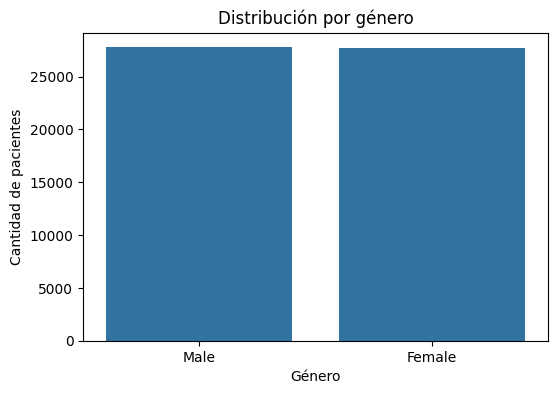

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt


df_chart = df_final.select(
    "Gender",
    "Medical Condition",
    "Hospital",
    "Doctor",
    "Age"
)
pdf = df_chart.toPandas()
plt.figure(figsize=(6,4))
sns.countplot(data=pdf, x="Gender")
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de pacientes")
plt.show()


- La distribución de género es prácticamente igual, con cantidades similares de pacientes hombres y mujeres, lo que nos puede indicar que la atención médica no está concentrada en un género específico, sino que la demanda es homogénea.


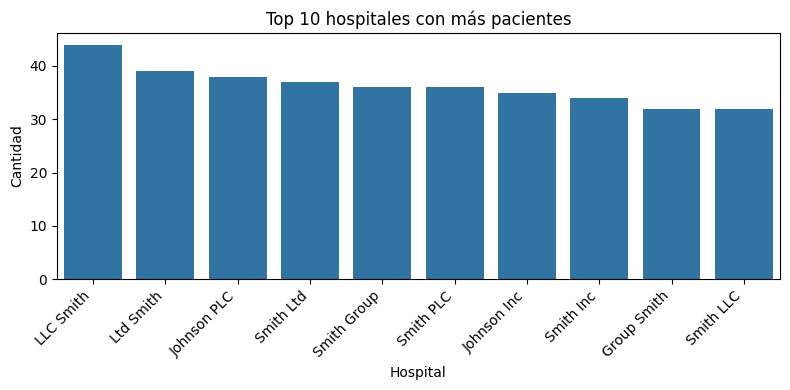

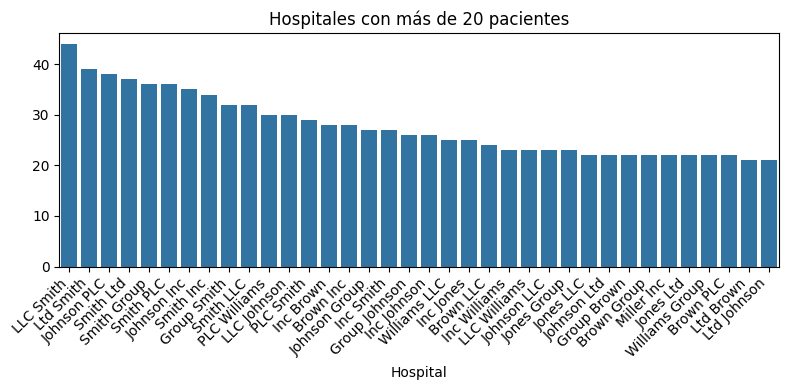

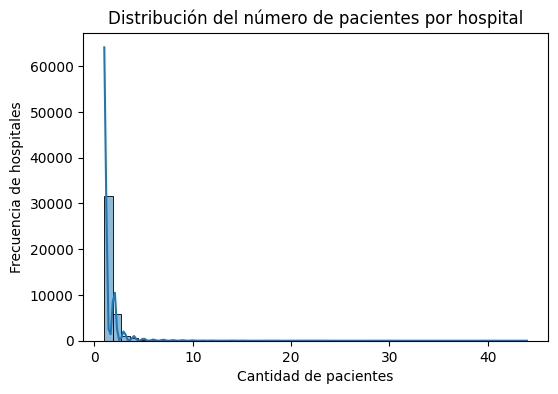

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_hospitals = pdf["Hospital"].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    x=top_hospitals.index,
    y=top_hospitals.values
)
plt.title("Top 10 hospitales con más pacientes")
plt.xlabel("Hospital")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


counts = pdf["Hospital"].value_counts()
filtered = counts[counts > 20]

plt.figure(figsize=(8,4))
sns.barplot(
    x=filtered.index,
    y=filtered.values
)
plt.title("Hospitales con más de 20 pacientes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

counts = pdf["Hospital"].value_counts()

plt.figure(figsize=(6,4))
sns.histplot(counts, bins=50, kde=True)
plt.title("Distribución del número de pacientes por hospital")
plt.xlabel("Cantidad de pacientes")
plt.ylabel("Frecuencia de hospitales")
plt.show()





**Grafica Top 10 hospitales con más pacientes** 
Los 10 hospitales más concurridos concentran una proporción significativa de pacientes, destacándose algunos con volúmenes entre 35 y 45 casos.

**Grafica Hospitales con más de 20 pacientes**
Solo un subconjunto reducido de hospitales supera los 20 pacientes, lo que evidencia una distribución desigual de la carga asistencial y en estos hospitales, el volumen se mantiene dentro de un rango relativamente similar, lo que indica que comparten una demanda comparable.

**Garfica Distribución del número de pacientes por hospital**
La distribución está altamente sesgada hacia la izquierda, con la mayoría de hospitales atendiendo muy pocos pacientes, y solo unos pocos alcanzando valores altos.

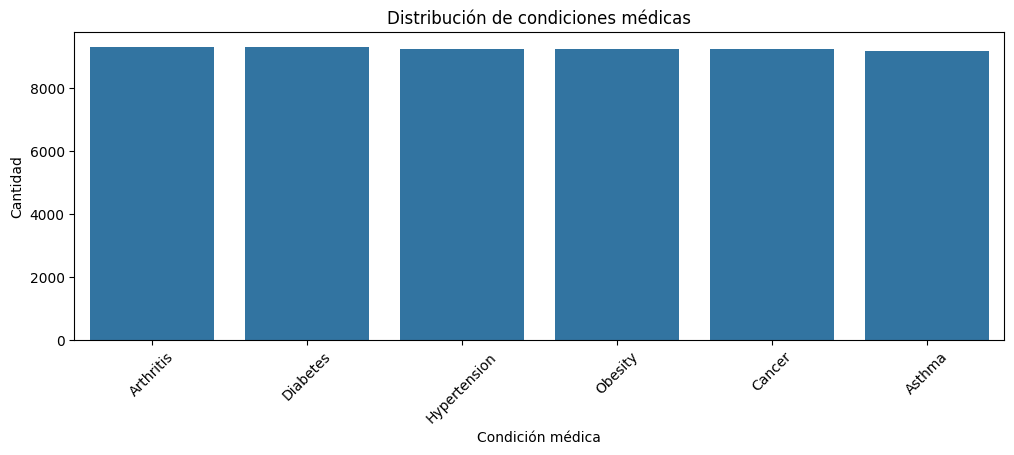

In [0]:
plt.figure(figsize=(12,4))
sns.countplot(data=pdf, x="Medical Condition", order=pdf["Medical Condition"].value_counts().index)
plt.title("Distribución de condiciones médicas")
plt.xlabel("Condición médica")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()



La distribución de pacientes por condición médica es bastante uniforme entre las seis enfermedades registradas, con valores cercanos entre sí.

Lo que puede significar que no existe una enfermedad dominante en la base de datos, sino que los casos están repartidos de manera equilibrada entre los principales diagnósticos.

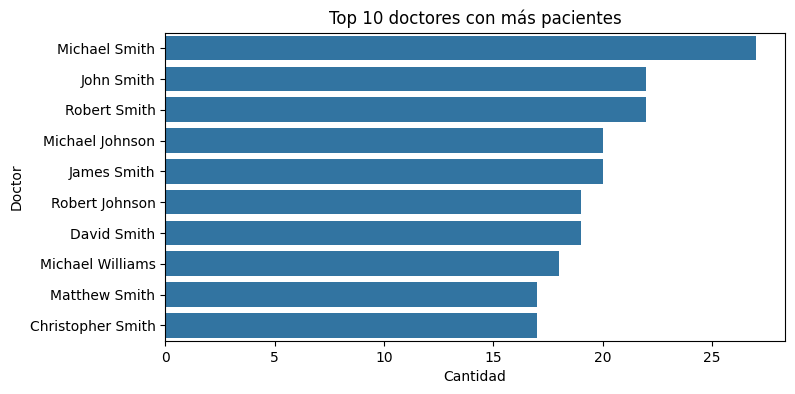

In [0]:
top_doctors = pdf["Doctor"].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_doctors.values, y=top_doctors.index)
plt.title("Top 10 doctores con más pacientes")
plt.xlabel("Cantidad")
plt.ylabel("Doctor")
plt.show()


- La mayoría de los médicos en el top comparten el mismo apellido (Smith), lo que sugiere equipos médicos grandes o especialidades con alta demanda.
- Los doctores con más pacientes presentan volúmenes relativamente similares, aunque algunos pocos (como Michael Smith) destacan ligeramente sobre el resto.